In [3]:
!nvidia-smi
!which ncu
!ncu --version

Tue Oct  6 04:26:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!nvcc -O3 -arch=sm_75 \
  /content/attention_baseline.cu \
  -o /content/attention_baseline

In [5]:
!ls -lh /content/attention_baseline

-rwxr-xr-x 1 root root 987K Oct  6 04:28 /content/attention_baseline


In [13]:
!/content/attention_baseline

=== GPU Attention Baseline V0 ===
Sequence Length : 512
Heads           : 12
Head Dimension  : 64
Precision       : FP16
Warmup          : 20
Iterations      : 100


=== Kernel Timing ===
QK Time      : 3.57684 ms
Softmax Time : 0.140607 ms
PV Time      : 0.727831 ms

=== Benchmark ===
Total Time : 465.545 ms
Avg Time   : 4.65545 ms

=== Validation ===
Max Error  : 5.37187e-06
Validation : PASSED


In [6]:
!ncu --set basic \
  --export /content/test.ncu-rep \
  /content/attention_baseline

=== GPU Attention Baseline V0 ===
Sequence Length : 512
Heads           : 12
Head Dimension  : 64
Precision       : FP16
Warmup          : 20
Iterations      : 100

==PROF== Connected to process 1836 (/content/attention_baseline)
==PROF== Profiling "qkKernel" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 7: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 8: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 9: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 10: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 11: 0%....50%

In [7]:
!ls -lh /content/test.ncu-rep

-rw-r--r-- 1 root root 27M Oct  6 04:48 /content/test.ncu-rep


In [8]:
from google.colab import files

files.download('/content/test.ncu-rep')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
!nvcc -O3 -arch=sm_75 \
/content/attention_qk_shared_v1.cu \
-o /content/attention_qk_shared_v1

In [10]:
!ls -lh /content/attention_qk_shared_v1

-rwxr-xr-x 1 root root 995K Oct  6 05:24 /content/attention_qk_shared_v1


In [11]:
!/content/attention_qk_shared_v1

=== GPU Attention Baseline V0 ===
Sequence Length : 512
Heads           : 12
Head Dimension  : 64
Precision       : FP16
Warmup          : 20
Iterations      : 100


=== Kernel Timing ===
QK Time      : 1.74121 ms
Softmax Time : 0.14073 ms
PV Time      : 0.720315 ms

=== Benchmark ===
Total Time : 344.829 ms
Avg Time   : 3.44829 ms

=== Validation ===
Max Error  : 5.37187e-06
Validation : PASSED


In [12]:
!ncu --set basic \
--export /content/attention_qk_shared_v1.ncu-rep \
/content/attention_qk_shared_v1

=== GPU Attention Baseline V0 ===
Sequence Length : 512
Heads           : 12
Head Dimension  : 64
Precision       : FP16
Warmup          : 20
Iterations      : 100

==PROF== Connected to process 21898 (/content/attention_qk_shared_v1)
==PROF== Profiling "qkKernel" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 7: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 8: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 9: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 10: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 11: 0%..

In [14]:
!nvcc -O3 -arch=sm_75 \
/content/attention_pv_shared_v2.cu \
-o /content/attention_pv_shared_v2

In [15]:
!ls -lh /content/attention_pv_shared_v2

-rwxr-xr-x 1 root root 995K Oct  6 06:39 /content/attention_pv_shared_v2


In [16]:
!/content/attention_pv_shared_v2

=== GPU Attention V2 (QK + PV shared memory) ===
Sequence Length : 512
Heads           : 12
Head Dimension  : 64
Precision       : FP16
Warmup          : 20
Iterations      : 100


=== Kernel Timing ===
QK Time      : 1.74888 ms
Softmax Time : 0.140632 ms
PV Time      : 0.417794 ms

=== Benchmark ===
Total Time : 256.644 ms
Avg Time   : 2.56644 ms

=== Validation ===
Max Error  : 5.37187e-06
Validation : PASSED


In [17]:
!ncu --set basic \
--export /content/attention_pv_shared_v2.ncu-rep \
/content/attention_pv_shared_v2

=== GPU Attention V2 (QK + PV shared memory) ===
Sequence Length : 512
Heads           : 12
Head Dimension  : 64
Precision       : FP16
Warmup          : 20
Iterations      : 100

==PROF== Connected to process 46747 (/content/attention_pv_shared_v2)
==PROF== Profiling "qkKernel" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 7: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKernel" - 8: 0%....50%....100% - 9 passes
==PROF== Profiling "qkKernel" - 9: 0%....50%....100% - 9 passes
==PROF== Profiling "softmaxKernel" - 10: 0%....50%....100% - 9 passes
==PROF== Profiling "pvKer

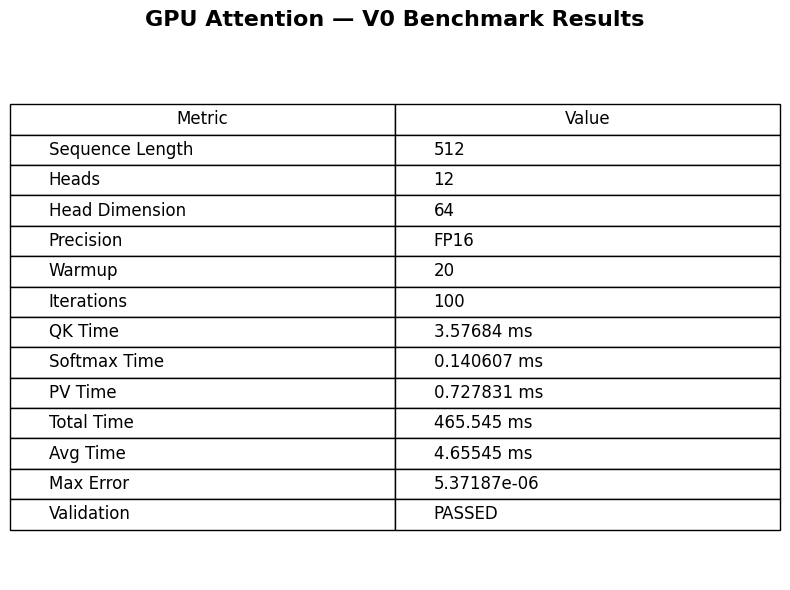

Saved: /content/v0_benchmark_results.png


In [18]:
import matplotlib.pyplot as plt

data = [
    ["Sequence Length", "512"],
    ["Heads", "12"],
    ["Head Dimension", "64"],
    ["Precision", "FP16"],
    ["Warmup", "20"],
    ["Iterations", "100"],
    ["QK Time", "3.57684 ms"],
    ["Softmax Time", "0.140607 ms"],
    ["PV Time", "0.727831 ms"],
    ["Total Time", "465.545 ms"],
    ["Avg Time", "4.65545 ms"],
    ["Max Error", "5.37187e-06"],
    ["Validation", "PASSED"],
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=["Metric", "Value"],
    cellLoc="left",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.6)

plt.title(
    "GPU Attention — V0 Benchmark Results",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

output = "/content/v0_benchmark_results.png"
plt.savefig(output, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {output}")

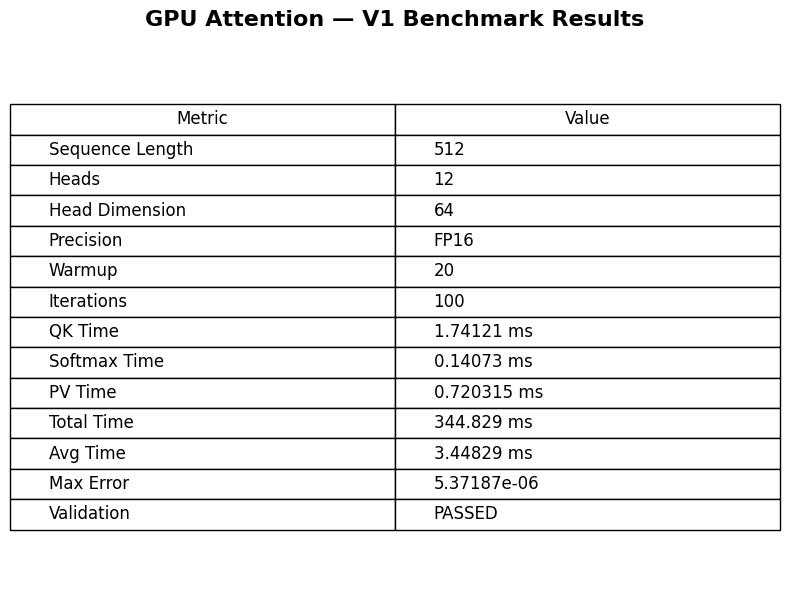

Saved: /content/v1_benchmark_results.png


In [19]:
import matplotlib.pyplot as plt

data = [
    ["Sequence Length", "512"],
    ["Heads", "12"],
    ["Head Dimension", "64"],
    ["Precision", "FP16"],
    ["Warmup", "20"],
    ["Iterations", "100"],
    ["QK Time", "1.74121 ms"],
    ["Softmax Time", "0.14073 ms"],
    ["PV Time", "0.720315 ms"],
    ["Total Time", "344.829 ms"],
    ["Avg Time", "3.44829 ms"],
    ["Max Error", "5.37187e-06"],
    ["Validation", "PASSED"],
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=["Metric", "Value"],
    cellLoc="left",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.6)

plt.title(
    "GPU Attention — V1 Benchmark Results",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

output = "/content/v1_benchmark_results.png"
plt.savefig(output, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {output}")

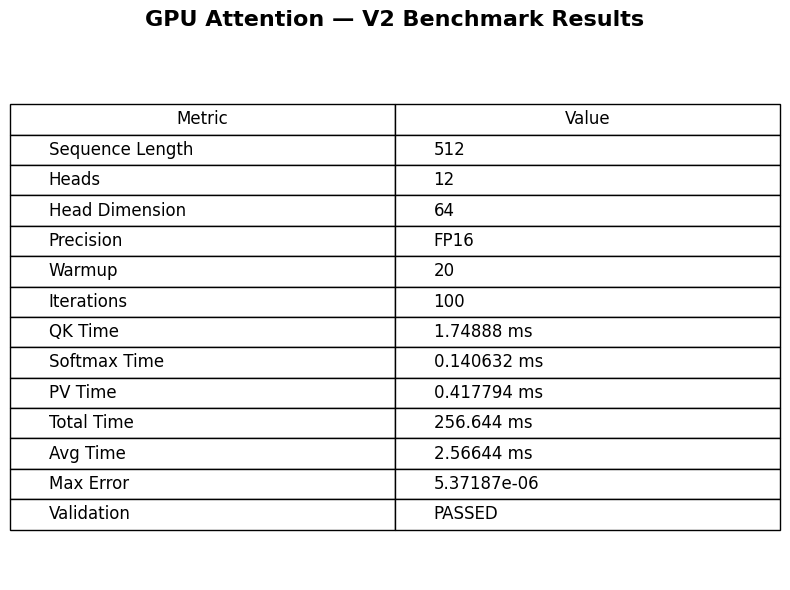

Saved: /content/v2_benchmark_results.png


In [20]:
import matplotlib.pyplot as plt

data = [
    ["Sequence Length", "512"],
    ["Heads", "12"],
    ["Head Dimension", "64"],
    ["Precision", "FP16"],
    ["Warmup", "20"],
    ["Iterations", "100"],
    ["QK Time", "1.74888 ms"],
    ["Softmax Time", "0.140632 ms"],
    ["PV Time", "0.417794 ms"],
    ["Total Time", "256.644 ms"],
    ["Avg Time", "2.56644 ms"],
    ["Max Error", "5.37187e-06"],
    ["Validation", "PASSED"],
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=["Metric", "Value"],
    cellLoc="left",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.6)

plt.title(
    "GPU Attention — V2 Benchmark Results",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

output = "/content/v2_benchmark_results.png"
plt.savefig(output, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {output}")